# Lernlabor · Ein Netz lernt Symbole
**Gemeinsam ausprobieren · ca. 20–30 Minuten · keine benotete Abgabe**

Wir lernen die Arbeitsweise kennen, bevor wir eigene Daten verwenden. Alle Zeichnungen hier sind **künstlich erzeugt**. Die Personencodes stehen für simulierte Zeichenstile, nicht für echte Personen.

**Heute können Sie:** Eingaben und Labels benennen, Training von Vorhersage unterscheiden und eine Fehlvorhersage untersuchen.

Codezellen mit **Shift + Enter** ausführen. Vermutungen zuerst notieren, Ergebnisse danach betrachten. Neben diesem Notebook muss `ki_projekt_tools.py` liegen (in JupyterLite bereits enthalten). Bei einem fehlenden Import prüfen, ob beide Dateien im gleichen Ordner liegen.

[Projektauftrag](ki_projektauftrag.md) · [Danach: eigenes Projektjournal](ki_tandemprojekt.ipynb)

**Gespeicherte Beispielausgaben:** synthetische Demo. Zellen neu ausführen, um den Ablauf selbst nachzuvollziehen.

In [1]:
# Einmal starten; die übrigen technischen Funktionen liegen in ki_projekt_tools.py.
import sys
if sys.platform == 'emscripten':
    import pyodide_js
    await pyodide_js.loadPackage(['numpy', 'scipy', 'scikit-learn', 'matplotlib'])

import ki_projekt_tools as ki
print('Werkzeuge bereit:', ki.VERSION)


Werkzeuge bereit: 2.0


## 1 · Welche Daten sieht ein Netz?
**Frage:** Wie wird aus einer Zeichnung eine Eingabe für ein neuronales Netz?  
**Vermutung:** …

**Experiment:** Laden Sie die Demodaten und betrachten Sie einige Trainingsbilder.

DEMO: 360 Bilder; 3 Klassen. Testvorhersagen noch nicht berechnet.
Person | Pfeil | Herz | Stern
P01 | 15 | 15 | 15
P02 | 15 | 15 | 15
P03 | 15 | 15 | 15
P04 | 15 | 15 | 15
P05 | 15 | 15 | 15
P06 | 15 | 15 | 15


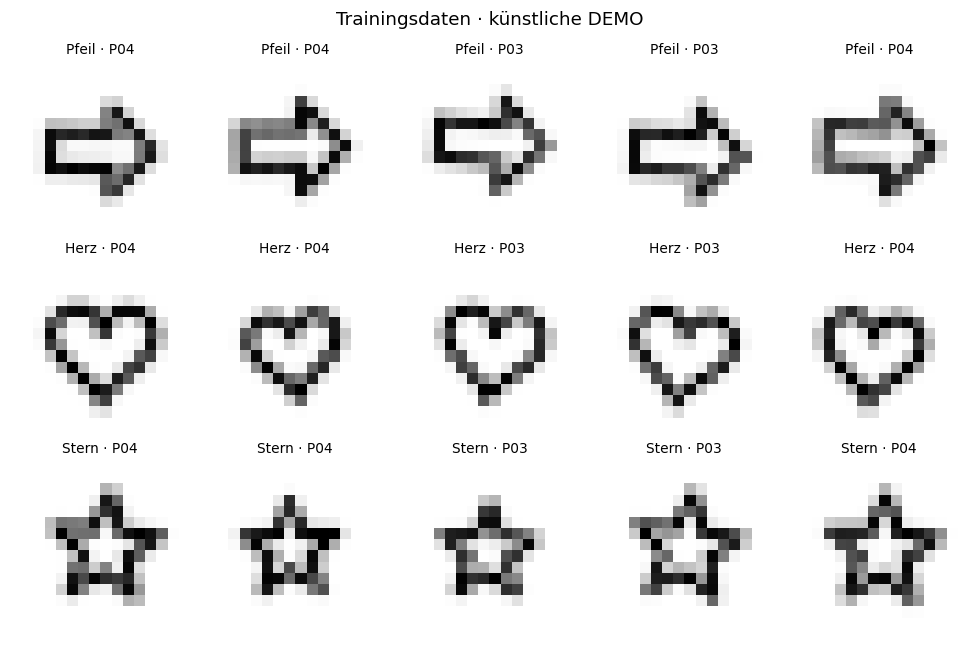

In [2]:
daten = ki.daten_laden()
ki.daten_ansehen(daten)

**Beleg:** Beschreiben Sie zwei Unterschiede zwischen Bildern derselben Klasse. …  
**Schlussfolgerung:** Was ist die Eingabe? Was ist das Label? …

Jedes Bild besteht aus **16 × 16 = 256 Zahlen**: 0 ist Hintergrund, 1 ein dunkler Strich. Das Label ist die vorgegebene Symbolklasse. Die Zahlencodes P01 usw. sind Metadaten für die Aufteilung, **keine Eingaben des Netzes**.

## 2 · Was verändert sich beim Training?
**Frage:** Welche Zahlen lernt das Netz?  
**Vermutung:** …  
**Experiment:** Betrachten Sie den Aufbau, trainieren Sie das Ausgangsmodell und lesen Sie den Verlauf.

6243 trainierbare Gewichte und Biaswerte.
DEMO · ausgang · Validierung: 90 Bilder / 2 Personen
Variante | Lauf | Trainingsbilder | Training | Validierung
A | 11 | 72 | 100.0% | 97.8%


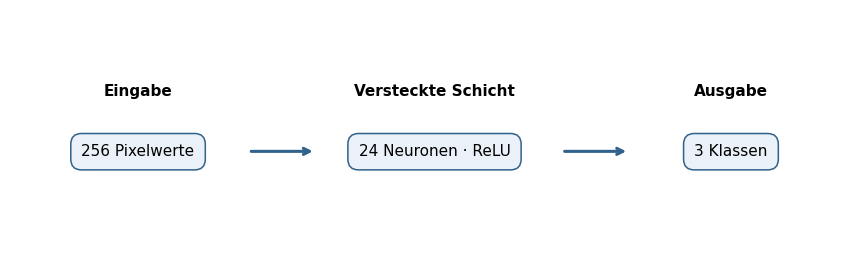

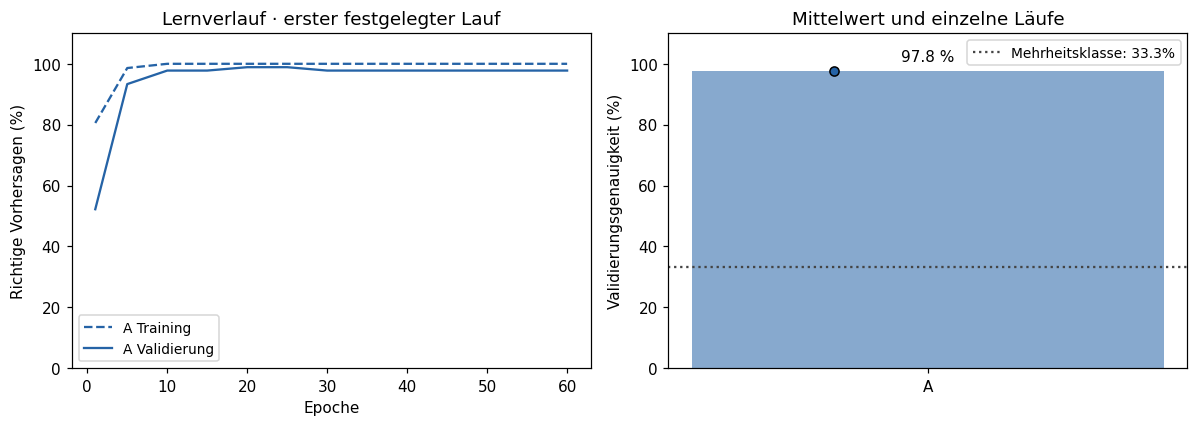

In [3]:
ki.netz_zeigen(neuronen=24, klassen=daten.klassen)
ausgang = ki.ausgangsmodell(daten)
ki.ergebnisse_zeigen(ausgang)

**Beleg:** Notieren Sie Training und Validierung am Ende: …  
**Schlussfolgerung:** Weshalb sind das zwei verschiedene Werte? …

Eine **Epoche** verwendet alle ausgewählten Trainingsbilder einmal zum Lernen. Dabei ändern sich Gewichte und Biaswerte. Bei einer **Vorhersage** bleiben sie unverändert. Die versteckte Schicht verwendet ReLU als nichtlineare Aktivierungsfunktion. Die Validierung dient zum Vergleichen; sie verändert keine Gewichte.

## 3 · Hat das Netz das Symbol wirklich erkannt?
**Frage:** Welche Symbole verwechselt das Netz?  
**Vermutung:** …  
**Experiment:** Untersuchen Sie die Verwechslungstabelle und einzelne falsche Vorhersagen.

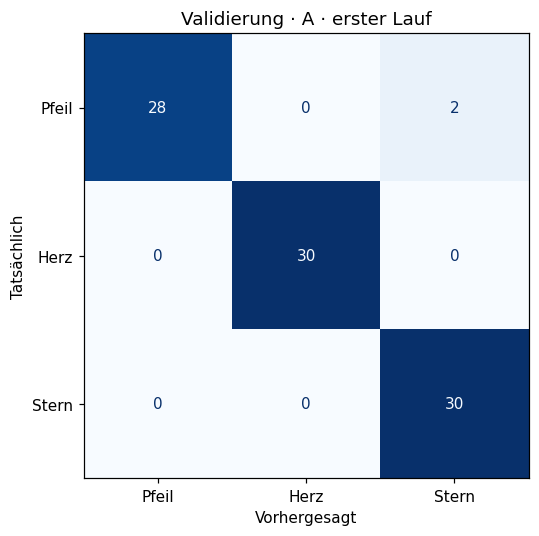

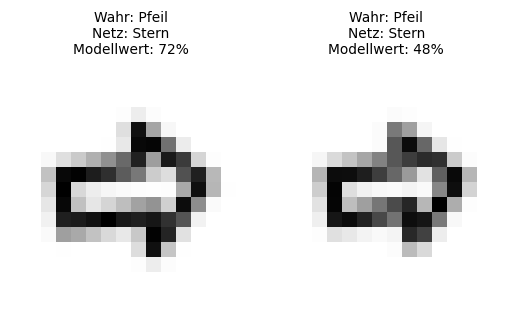

In [4]:
ki.fehler_zeigen(ausgang, variante='A')

**Beleg:** Beschreiben Sie eine konkrete Verwechslung. Falls keine auftritt: Was wäre trotzdem noch ungeprüft? …  
**Schlussfolgerung:** Warum beweist ein hoher Modellwert keine richtige Antwort? …

Zeilen der Tabelle: tatsächliche Klasse. Spalten: Vorhersage. Die Diagonale zählt richtige Vorhersagen. Ein Modellwert von 90 % ist keine Garantie für 90 % Richtigkeit im Alltag.

## 4 · Welchen Versuch würden wir planen?
Wählen Sie **eine** Frage für das anschliessende Projekt:
- **Menge:** Helfen mehr Trainingsbilder?
- **Vielfalt:** Helfen Zeichnungen von mehr Personen?
- **Netz:** Hilft eine grössere versteckte Schicht?

**Frage:** …  
**Vermutung und Begründung:** …  
**Was verändern wir?** …  
**Was halten wir konstant?** …  
**Welches Ergebnis würde unsere Vermutung infrage stellen?** …

Besprechen Sie Ihre Idee kurz mit einem anderen Tandem. Anschliessend arbeiten Sie im [Projektjournal](ki_tandemprojekt.ipynb) weiter. Die Demodaten werden nicht als eigene Datensammlung abgegeben.